# Phase 1, Experiment 1.3 — Tweedie regression

A single-stage alternative to the 1.2 hurdle. Tweedie's compound Poisson-Gamma family (power between 1 and 2) natively models a target with a point mass at zero and a continuous positive component — which is what FPL points look like after we clip negatives.

The bar to beat is the 1.2 hurdle: R² = 0.6386, MAE = 0.7116. Tweedie's appeal is parsimony — one model, one feature pipeline, one set of coefficients, no calibration step. The cost is a more restrictive parametric form: the variance-mean relationship is fixed by the `power` parameter rather than learned separately for the zero and positive components.

We sweep a 2D grid: `power ∈ {1.1, 1.3, 1.5, 1.7, 1.9}` × `alpha ∈ {0.0, 0.01, 1.0}`. Picking power at a fixed default alpha would conflate the family-shape effect with the regularization effect.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import TweedieRegressor, Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

sys.path.insert(0, str(Path.cwd()))
from src.config import PROCESSED_PATH, get_feature_group, get_splits

pd.set_option("display.float_format", "{:.4f}".format)
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [2]:
df = pd.read_csv(PROCESSED_PATH)
train_mask, val_mask, test_mask = get_splits(df)

# Helpers
def feature_columns(groups):
    cols = []
    for g in groups:
        cols.extend(get_feature_group(g))
    return cols


def build_X(df, mask, cols, scaler=None):
    X = df.loc[mask, cols].values
    if scaler is None:
        scaler = StandardScaler().fit(X)
    return scaler.transform(X), scaler


def evaluate(y_true, y_pred, positions=None):
    out = {"r2": r2_score(y_true, y_pred), "mae": mean_absolute_error(y_true, y_pred)}
    if positions is not None:
        for pos in ["GK", "DEF", "MID", "FWD"]:
            m = positions == pos
            if m.sum():
                out[f"mae_{pos}"] = mean_absolute_error(y_true[m], y_pred[m])
    return out


GROUPS = ["BASE_PREKICKOFF", "POSITION", "XP", "ICT_BLOCK", "OTHER_LAGS"]
cols = feature_columns(GROUPS)
val_positions = df.loc[val_mask, "position"].values

## Clip negatives and log impact

Tweedie with `power ∈ (1, 2)` requires y ≥ 0. We clip at zero. Yellow cards (−1), red cards (−3), own goals (−2) are essentially noise from a pre-kickoff features perspective — there is no signal in lag stats that predicts a sending-off — so the information loss is small. Document row counts so the writeup can quote them.

In [3]:
y_train_raw = df.loc[train_mask, "total_points"].values
y_val_raw = df.loc[val_mask, "total_points"].values

train_neg = (y_train_raw < 0).sum()
val_neg = (y_val_raw < 0).sum()

y_train = np.clip(y_train_raw, 0, None)
y_val = y_val_raw  # do NOT clip val — evaluation must be against the true target

print(f"train rows clipped: {train_neg:,} / {len(y_train_raw):,} ({train_neg/len(y_train_raw)*100:.2f}%)")
print(f"val rows with y<0:  {val_neg:,} / {len(y_val_raw):,} ({val_neg/len(y_val_raw)*100:.2f}%)")
print("Note: val target is NOT clipped — Tweedie predictions are evaluated against the true (unclipped) target,")
print("which is the same thing we did for hurdle and flat Ridge. Apples-to-apples.")

train rows clipped: 220 / 46,991 (0.47%)
val rows with y<0:  138 / 23,825 (0.58%)
Note: val target is NOT clipped — Tweedie predictions are evaluated against the true (unclipped) target,
which is the same thing we did for hurdle and flat Ridge. Apples-to-apples.


## Feature matrix

Same columns as 1.1 and 1.2: `BASE_PREKICKOFF + POSITION + XP + ICT_BLOCK + OTHER_LAGS`. Standardize fit on full train. The single-stage architecture means no scaler pair to manage.

In [4]:
X_train, scaler = build_X(df, train_mask, cols)
X_val, _ = build_X(df, val_mask, cols, scaler=scaler)
print(f"X_train: {X_train.shape}   X_val: {X_val.shape}   features: {len(cols)}")

X_train: (46991, 45)   X_val: (23825, 45)   features: 45


## Tweedie 2D sweep

`power=1` reduces to Poisson (count data); `power=2` reduces to Gamma (strictly positive continuous, no zeros). Values in (1, 2) are compound Poisson-Gamma — what we want for zero-inflated continuous targets. The right power is empirical.

`link='auto'` picks log-link for power > 0 — the standard choice. Predictions on the original scale are `exp(Xβ)`, guaranteed non-negative, matching our clipped target.

In [5]:
POWERS = [1.1, 1.3, 1.5, 1.7, 1.9]
ALPHAS = [0.0, 0.01, 1.0]

records = []
for p in POWERS:
    for a in ALPHAS:
        m = TweedieRegressor(power=p, alpha=a, link="auto", max_iter=2000)
        m.fit(X_train, y_train)
        pred = m.predict(X_val)
        records.append({
            "power": p, "alpha": a,
            "r2": r2_score(y_val, pred),
            "mae": mean_absolute_error(y_val, pred),
        })

sweep = pd.DataFrame(records)
print(sweep.to_string(index=False))

 power  alpha       r2    mae
1.1000 0.0000   0.5111 0.8597
1.1000 0.0100   0.5113 0.8619
1.1000 1.0000   0.4305 0.9661
1.3000 0.0000   0.4493 0.8346
1.3000 0.0100   0.4541 0.8360
1.3000 1.0000   0.4110 0.9481
1.5000 0.0000   0.1656 0.8334
1.5000 0.0100   0.1943 0.8334
1.5000 1.0000   0.3845 0.9352
1.7000 0.0000  -1.8390 0.9116
1.7000 0.0100  -1.5517 0.9038
1.7000 1.0000   0.3285 0.9317
1.9000 0.0000 -42.0636 1.3751
1.9000 0.0100 -32.7152 1.3196
1.9000 1.0000   0.1128 0.9560


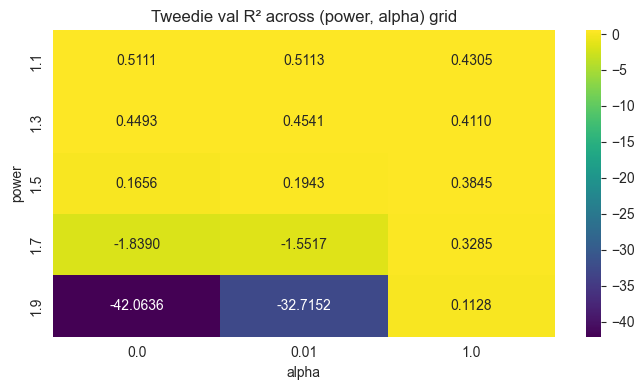

In [6]:
# Heatmap of val R² across (power, alpha)
pivot = sweep.pivot(index="power", columns="alpha", values="r2")

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis", ax=ax)
ax.set_title("Tweedie val R² across (power, alpha) grid")
plt.tight_layout()
plt.show()

## Best Tweedie — refit and full metrics

Pick the grid cell with highest val R², refit, report full per-position MAE for diagnosis.

In [7]:
best = sweep.loc[sweep["r2"].idxmax()]
best_power, best_alpha = best["power"], best["alpha"]
print(f"best power={best_power}, alpha={best_alpha}, val R²={best['r2']:.4f}, MAE={best['mae']:.4f}\n")

best_tweedie = TweedieRegressor(power=best_power, alpha=best_alpha, link="auto", max_iter=2000)
best_tweedie.fit(X_train, y_train)
pred_tweedie = best_tweedie.predict(X_val)
tweedie_metrics = evaluate(y_val, pred_tweedie, val_positions)

print("Tweedie (best, full val):")
for k, v in tweedie_metrics.items():
    print(f"  {k}: {v:.4f}")

best power=1.1, alpha=0.01, val R²=0.5113, MAE=0.8619

Tweedie (best, full val):
  r2: 0.5113
  mae: 0.8619
  mae_GK: 0.5875
  mae_DEF: 0.9022
  mae_MID: 0.8790
  mae_FWD: 0.9477


## Diagnostics

Actual vs predicted scatter (looking for systematic over/underprediction in the high-points tail) and residuals by position. Compare visually to 1.2 hurdle's analogous plots — if Tweedie's residual structure differs systematically by position, that's a clue about why one model wins.

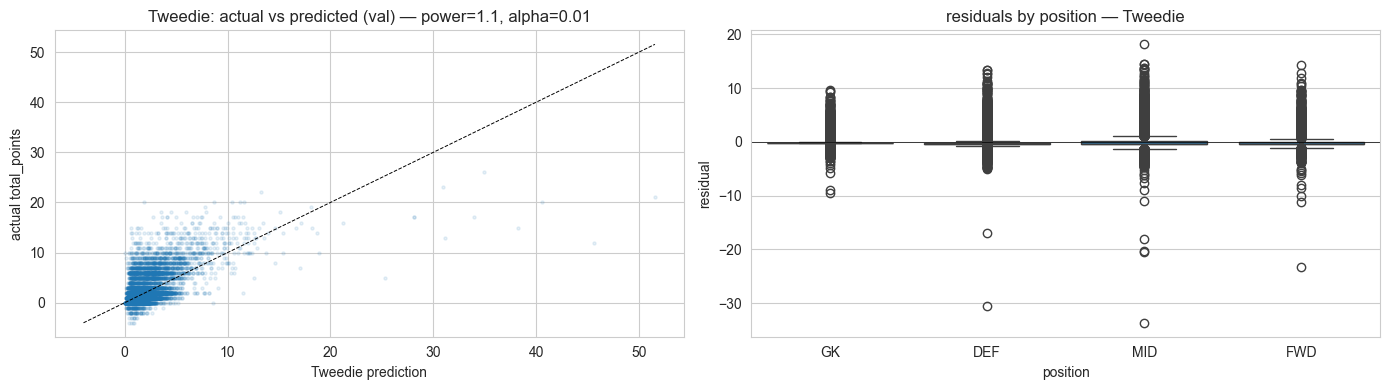

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(pred_tweedie, y_val, alpha=0.1, s=5)
lim = [min(pred_tweedie.min(), y_val.min()), max(pred_tweedie.max(), y_val.max())]
axes[0].plot(lim, lim, "k--", linewidth=0.7)
axes[0].set_xlabel("Tweedie prediction")
axes[0].set_ylabel("actual total_points")
axes[0].set_title(f"Tweedie: actual vs predicted (val) — power={best_power}, alpha={best_alpha}")

resid_df = pd.DataFrame({"position": val_positions, "residual": y_val - pred_tweedie})
sns.boxplot(data=resid_df, x="position", y="residual", order=["GK", "DEF", "MID", "FWD"], ax=axes[1])
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("residuals by position — Tweedie")

plt.tight_layout()
plt.show()

## Refit hurdle for the head-to-head comparison

Rebuild the 1.2 hurdle (LR stage 1 + Ridge α=1 stage 2) so we can sit Tweedie next to it on the same val rows in one table. No re-tuning here — exact configuration locked from 1.2.

In [9]:
y_train_play = df.loc[train_mask, "played_any"].values
played_train_mask = train_mask & (df["played_any"] == 1)
y_train_played_pts = df.loc[played_train_mask, "total_points"].values

X_train_s2_played, scaler_s2 = build_X(df, played_train_mask, cols)
X_val_s2_full, _ = build_X(df, val_mask, cols, scaler=scaler_s2)

lr = LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE).fit(X_train, y_train_play)
p_play_val = lr.predict_proba(X_val)[:, 1]

ridge_s2 = Ridge(alpha=1.0).fit(X_train_s2_played, y_train_played_pts)
e_pts_val = ridge_s2.predict(X_val_s2_full)

pred_hurdle = p_play_val * e_pts_val
hurdle_metrics = evaluate(y_val, pred_hurdle, val_positions)

print("Hurdle (1.2 reproduction, full val):")
for k, v in hurdle_metrics.items():
    print(f"  {k}: {v:.4f}")

Hurdle (1.2 reproduction, full val):
  r2: 0.6386
  mae: 0.7116
  mae_GK: 0.4447
  mae_DEF: 0.7424
  mae_MID: 0.7474
  mae_FWD: 0.7524


## Updated results table

In [10]:
flat_ridge = Ridge(alpha=1.0).fit(X_train, df.loc[train_mask, "total_points"].values)
flat_pred = flat_ridge.predict(X_val)
flat_metrics = evaluate(y_val, flat_pred, val_positions)

results = {
    "xP passthrough": evaluate(y_val, df.loc[val_mask, "xP"].values, val_positions),
    "Ridge flat (1.1, alpha=1)": flat_metrics,
    "Hurdle (1.2, LR + Ridge alpha=1)": hurdle_metrics,
    f"Tweedie (1.3, power={best_power}, alpha={best_alpha})": tweedie_metrics,
}
results_df = pd.DataFrame(results).T
print(results_df)

                                         r2    mae  mae_GK  mae_DEF  mae_MID  \
xP passthrough                       0.5169 0.8129  0.6629   0.8449   0.8271   
Ridge flat (1.1, alpha=1)            0.5989 0.8275  0.6787   0.8451   0.8370   
Hurdle (1.2, LR + Ridge alpha=1)     0.6386 0.7116  0.4447   0.7424   0.7474   
Tweedie (1.3, power=1.1, alpha=0.01) 0.5113 0.8619  0.5875   0.9022   0.8790   

                                      mae_FWD  
xP passthrough                         0.8187  
Ridge flat (1.1, alpha=1)              0.8834  
Hurdle (1.2, LR + Ridge alpha=1)       0.7524  
Tweedie (1.3, power=1.1, alpha=0.01)   0.9477  


## Pick the structured-zero-inflation winner for 1.4

The 1.4 PCA experiment runs on the winner of {hurdle, Tweedie}. Decision rule below; if within ~0.005 R² we treat them as tied and prefer hurdle for the better headline R² already established in 1.2.

In [11]:
hurdle_r2 = hurdle_metrics["r2"]
tweedie_r2 = tweedie_metrics["r2"]
delta = hurdle_r2 - tweedie_r2

if delta > 0.005:
    winner = "hurdle"
elif delta < -0.005:
    winner = "tweedie"
else:
    winner = "tied — prefer hurdle for stronger 1.2 baseline"

print(f"Hurdle val R²:  {hurdle_r2:.4f}")
print(f"Tweedie val R²: {tweedie_r2:.4f}")
print(f"Δ (hurdle - tweedie): {delta:+.4f}")
print(f"\nWinner for 1.4 PCA experiment: {winner}")

Hurdle val R²:  0.6386
Tweedie val R²: 0.5113
Δ (hurdle - tweedie): +0.1273

Winner for 1.4 PCA experiment: hurdle


## Decisions to record for writeup

1. Negative target handling: clip y to zero before fitting Tweedie. Train rows affected: see cell output. Rationale: Tweedie with power ∈ (1, 2) requires y ≥ 0; pre-kickoff features have no predictive signal for cards or own goals, so the information loss is minimal. The val target is **not** clipped — evaluation is against the true target for fair comparison with hurdle and flat Ridge.

2. Power and alpha selected jointly via 2D grid search rather than power at fixed default alpha. Rationale: alpha (Tweedie's L2) and power (variance-mean shape) interact, so picking power at a default alpha would conflate the two effects.

3. Link function: `link='auto'` (defaults to log for power > 0). Rationale: log link is the standard choice for compound Poisson-Gamma; predictions are guaranteed non-negative, matching the clipped target.

4. Feature set: identical to 1.1 and 1.2 (`BASE_PREKICKOFF + POSITION + XP + ICT_BLOCK + OTHER_LAGS`, no CLUSTER). Single scaler fit on full train — no scaler pair like the hurdle.

5. Comparison to hurdle is on the same val rows with the same target. Tweedie's parameter count is roughly 1× the hurdle's (the hurdle has two coefficient vectors); a tied result favors Tweedie on parsimony grounds, a clear hurdle win means the decoupled architecture matters.